## Generate a sinthetic data to work

In [151]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
import porespy as ps

In [152]:
import porespy as ps

# Generate a synthetic 2D porous material image
im = ps.generators.blobs(shape=[300, 300], porosity=0.28, blobiness=1)
im = im.astype('uint8')
# Threshold the image to separate void space and solid matrix
threshold_value = 0.5  # Adjust this threshold as needed
#binary_image = (im > threshold_value).astype(int)
binary_image = im > threshold_value
# Label connected components in the binary image
labeled_image, num_labels = ndi.label(binary_image)

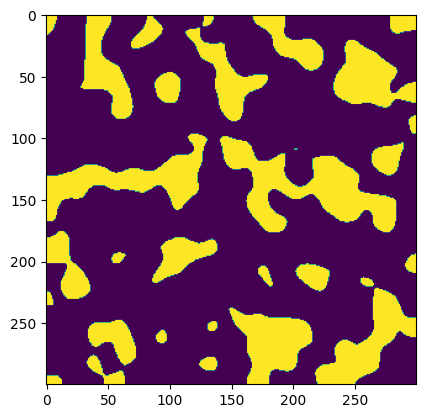

In [153]:
plt.imshow(im)

In [154]:
# Lista para salvar as regiões segmentadas (void space)
regioes_segmentadas = []

# Lista para salvar as coordenadas de cada região
coordenadas_poros = []

# Iterar sobre os diferentes rótulos de regiões na imagem rotulada
for label in range(1, num_labels + 1):
    # Encontrar os índices dos pixels da região na imagem rotulada
    indices_regiao = np.where(labeled_image == label)

    # Salvar as coordenadas x e y dos pixels da região na imagem original
    coords_x, coords_y = indices_regiao[1], indices_regiao[0]
    coordenadas_poros.append((coords_x, coords_y))

    # Extrair a região segmentada (void space) da imagem original
    regiao_segmentada = np.zeros_like(im)
    regiao_segmentada[coords_y, coords_x] = 1  # Atribuir 1 aos pixels da região
    regioes_segmentadas.append(regiao_segmentada)


Random number: 3


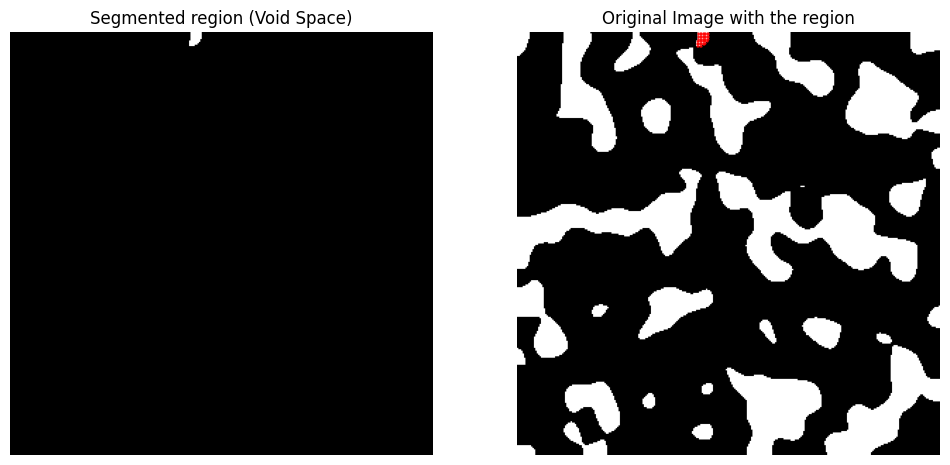

In [155]:
import random
random_number = random.randint(0, len(regioes_segmentadas))  # Generates a random integer between 1 and 100 (inclusive)
print("Random number:", random_number)

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]



# Visualizar a região segmentada e as coordenadas
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(regiao_segmentada_desejada, cmap='gray')
plt.title('Segmented region (Void Space)')
plt.axis('off')

plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Original Image with the region')
plt.axis('off')

plt.show()

## Apply the cluster tecnique: k means

In [156]:
# The number of pixels to consider a pore
pore_number = 60

In [157]:
import numpy as np
from sklearn.cluster import KMeans
from skimage.measure import find_contours

def apply_kmeans_to_region(region_segmentada, pore_number):
    # Obter os pixels que são representados por 1 na região segmentada
    pixels_0 = np.argwhere(region_segmentada == 1)

    # Determinar o número de vezes que len(pixels_0) excede pore_number
    excessos = len(pixels_0) // pore_number

    # Ajustar o número de clusters com base nos excessos
    num_clusters = max(1, excessos)

    # Aplicar K-means aos pixels 0 para segmentá-los em clusters
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(pixels_0)

    # Obter os rótulos dos clusters atribuídos aos pixels 0
    labels = kmeans.labels_

    # Criar uma matriz com os rótulos dos clusters nas posições dos pixels 0
    clustered_region = np.zeros_like(region_segmentada)
    for label, pixel in zip(labels, pixels_0):
        clustered_region[pixel[0], pixel[1]] = label + 1  # Adicionar 1 para evitar label 0

    # Calcular os centros dos clusters
    cluster_centers = kmeans.cluster_centers_

    # Encontrar os contornos de cada cluster
    contornos_por_cluster = []
    for i in range(num_clusters):
        mask = clustered_region == (i + 1)  # Criar uma máscara para o cluster atual
        contornos = find_contours(mask, 0.5)  # Encontrar os contornos do cluster atual
        contornos_por_cluster.append(contornos)

    # Retornar a região clusterizada, o número de clusters, as coordenadas dos centros dos clusters e os contornos de cada cluster
    return clustered_region, num_clusters, cluster_centers, contornos_por_cluster



import numpy as np
from skimage.measure import label, regionprops

def calculate_aspect_ratios(clustered_region):
    # Rotular a imagem para obter clusters individuais
    labeled_image = label(clustered_region)
    regions = regionprops(labeled_image)

    aspect_ratios = []
    for region in regions:
        major_axis_length = region.major_axis_length
        minor_axis_length = region.minor_axis_length

        #print(f"Major axis length: {major_axis_length}, Minor axis length: {minor_axis_length}")  # Informações para depuração

        if major_axis_length > 0:  # Evitar divisão por zero
            aspect_ratio = minor_axis_length / major_axis_length
        else:
            aspect_ratio = 0
        aspect_ratios.append(aspect_ratio)

    return aspect_ratios


def calculate_areas(clustered_region):
    # Rotular a imagem para obter clusters individuais
    labeled_image = label(clustered_region)
    regions = regionprops(labeled_image)

    #aspect_ratios = []
    areas = []
    for region in regions:
        ##major_axis_length = region.major_axis_length
        ##minor_axis_length = region.minor_axis_length
        area = region.area

        # Calcular a razão de aspecto
        ##if major_axis_length > 0:  # Evitar divisão por zero
        ##    aspect_ratio = minor_axis_length / major_axis_length
        ##else:
        ##    aspect_ratio = 0
        
        ##aspect_ratios.append(aspect_ratio)
        areas.append(area)

    return areas


# Lista para armazenar as coordenadas dos centros de cada região clusterizada
coordenadas_centros_kmeans = []
resultados_kmeans = []
number_of_pores_kmeans = []
ratio_of_aspect_cluster_kmeans = []
areas_cluster_kmeans = []
contour_per_cluster = []

# Plotar as regiões segmentadas após a aplicação do K-means
for i, region_segmentada in enumerate(regioes_segmentadas, start=1):
    # Aplicar o K-means à região segmentada atual
    clustered_region_kmeans, n_por_kmeans, centros_kmeans, contour_k_means = apply_kmeans_to_region(region_segmentada, pore_number)

    # Armazenar as coordenadas dos centros dos clusters na lista
    coordenadas_centros_kmeans.append(centros_kmeans)
    resultados_kmeans.append(clustered_region_kmeans)
    number_of_pores_kmeans.append(n_por_kmeans)
    # Calcular as razões de aspecto dos clusters
    aspect_ratios_kmeans = calculate_aspect_ratios(clustered_region_kmeans)
    areas_kmeans = calculate_areas(clustered_region_kmeans)
    ratio_of_aspect_cluster_kmeans.append(aspect_ratios_kmeans)
    areas_cluster_kmeans.append(areas_kmeans)
    contour_per_cluster.append(contour_k_means)

In [158]:
len(resultados_kmeans), len(contour_per_cluster), len(number_of_pores_kmeans), len(coordenadas_centros_kmeans)

(30, 30, 30, 30)

## Separating the void spaces and the pore regions in lists (the index and the centers are saved)

In [159]:
set_of_pores = []
set_of_pores_index = []
set_of_iso_void = []
set_of_iso_void_index = []
set_of_iso_void_centers = []
set_of_pores_centers = []
# First we search the clusters that are a set of "pores"
for i in range(0, len(resultados_kmeans) - 1 ):
    if number_of_pores_kmeans[i] > 1:
        temp_save_pores = number_of_pores_kmeans[i]
        tem_save_pores_centers = coordenadas_centros_kmeans[i]
        temp_save_pores_index = i
        set_of_pores.append(temp_save_pores)
        set_of_pores_index.append(temp_save_pores_index)
        set_of_pores_centers.append(coordenadas_centros_kmeans)
    else:
        temp_save_void = number_of_pores_kmeans[i]
        temp_save_iso_void_centers = coordenadas_centros_kmeans[i]
        temp_save_void_index = i     
        set_of_iso_void.append(temp_save_void)
        set_of_iso_void_index.append(temp_save_void_index)
        set_of_iso_void_centers.append(temp_save_iso_void_centers)

In [160]:
# Checking the length of each list
len(set_of_pores), len(set_of_pores_index), len(set_of_iso_void), len(set_of_iso_void_index)

(18, 18, 11, 11)

In [161]:
random_index_check_void = random.randint(0, len(set_of_iso_void_index)-1)
# Checking the code with resultados_kmeans (void spaces)
(resultados_kmeans[set_of_iso_void_index[random_index_check_void]]).max(), set_of_iso_void[random_index_check_void], random_index_check_void

(1, 1, 7)

In [162]:
# Checking the code with resultados_kmeans (pores)
random_index_check_pore = random.randint(0, len(set_of_pores)-1)
(resultados_kmeans[set_of_pores_index[random_index_check_pore]]).max(), set_of_pores[random_index_check_pore], random_index_check_pore, set_of_pores_index[random_index_check_pore]

(7, 7, 12, 18)

In [163]:
region_segmentada.shape

(300, 300)

## Convert the void space into zero values pixels to estimate the tortuosity

In [164]:
# # Função para calcular a distância euclidiana entre dois pontos
# def euclidean_distance(p1, p2):
#     return np.linalg.norm(p1 - p2)

In [165]:
import random
# Number of connected regions acording to the cluster k means
len(set_of_pores)

18

In [166]:
# The code with resultados_kmeans (pores)
random_index_apply_pore = random.randint(0, len(set_of_pores)-1)

In [167]:
resultados_kmeans[0]

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

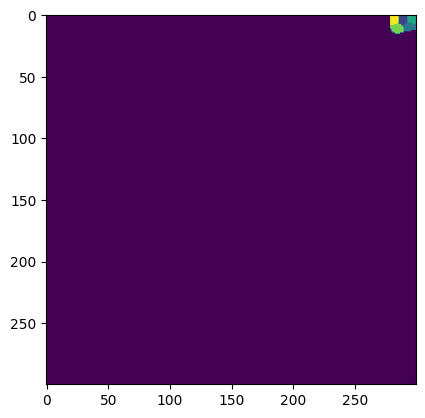

In [168]:
plt.imshow(resultados_kmeans[5])

In [169]:
resultados_kmeans[8].max(), len(coordenadas_centros_kmeans[8])

(7, 7)

In [170]:
# saving the list of connected regions to calculate the tortuosity
list_connected_regions = []
list_of_centers_connected_regions = []
c = 0
for i in set_of_pores_index:
    #print(i)
    temp_connected_region = resultados_kmeans[i]
    # Criar o tensor image_temp com valores acima de zero definidos como 1
    # Generate a tensor with image_temp to convert the values greater than zero to one
    temp_connected_region = np.where(temp_connected_region > 0, 1, 0)
    #temp_connected_region = temp_connected_region - 1
    # Inverte the void region to be represented by the zero pixels values
    temp_connected_region = 1 - temp_connected_region 
    temp_center_connected_region = coordenadas_centros_kmeans[i]
    list_connected_regions.append(temp_connected_region)
    list_of_centers_connected_regions.append(temp_center_connected_region)
##    c = c + 1
##    print(i)
##print("The total points", c)

In [171]:
list_connected_regions[0], list_of_centers_connected_regions[0]

(array([[1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        ...,
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1],
        [1, 1, 1, ..., 1, 1, 1]]),
 array([[35.41176471, 43.02941176],
        [67.01886792, 65.33962264],
        [17.48214286, 42.03571429],
        [57.27419355, 43.5       ],
        [50.78333333, 40.75      ],
        [12.8       , 35.44285714],
        [51.08450704, 49.84507042],
        [74.        , 57.        ],
        [ 3.01960784, 42.2745098 ],
        [30.63333333, 35.3       ],
        [53.25373134, 59.17910448],
        [56.48101266, 33.44303797],
        [ 4.23333333, 35.73333333],
        [38.61538462, 34.81538462],
        [10.47692308, 44.61538462],
        [74.        , 65.89473684],
        [60.03225806, 62.58064516],
        [41.6875    , 50.234375  ],
        [80.39622642, 64.03773585],
        [59.43478261, 52.68115942],
        [46.84375   , 34.09375   ],
        [26.        , 41.321428

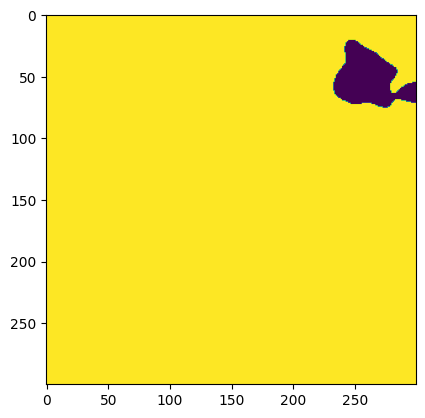

In [172]:
# Showing the connected regions 
random_show_connected =  random.randint(0, len(set_of_pores)-1)
plt.imshow(list_connected_regions[random_show_connected])

In [173]:
temp_connected_region[0]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [174]:
list_of_centers_connected_regions[1]

array([[12.20689655, 81.12068966],
       [23.37096774, 72.48387097],
       [ 4.3559322 , 84.59322034],
       [20.02702703, 78.18918919],
       [18.10526316, 85.85964912],
       [11.25757576, 89.89393939]])

In [175]:
list_connected_regions[0]

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]])

[[35.41176471 43.02941176]
 [67.01886792 65.33962264]
 [17.48214286 42.03571429]
 [57.27419355 43.5       ]
 [50.78333333 40.75      ]
 [12.8        35.44285714]
 [51.08450704 49.84507042]
 [74.         57.        ]
 [ 3.01960784 42.2745098 ]
 [30.63333333 35.3       ]
 [53.25373134 59.17910448]
 [56.48101266 33.44303797]
 [ 4.23333333 35.73333333]
 [38.61538462 34.81538462]
 [10.47692308 44.61538462]
 [74.         65.89473684]
 [60.03225806 62.58064516]
 [41.6875     50.234375  ]
 [80.39622642 64.03773585]
 [59.43478261 52.68115942]
 [46.84375    34.09375   ]
 [26.         41.32142857]
 [21.86885246 34.95081967]
 [66.59677419 57.37096774]
 [45.81666667 56.61666667]
 [ 3.89090909 49.12727273]
 [43.578125   42.65625   ]
 [80.56521739 57.04347826]]


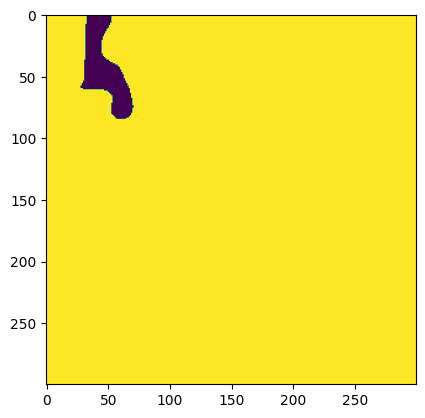

In [176]:
print(list_of_centers_connected_regions[0])
plt.imshow(list_connected_regions[0])

## Apply the route_through_array from skimage to estimate the tortuosity in each void space (pore region)

In [177]:
#This line of code is to save the list_connected_regions that has the clusterized regions
save_list = list_connected_regions
len(save_list)

18

In [148]:
# Run this line of code when you want restart the list to the original pixels
list_connected_regions = save_list

In [178]:
len(list_of_centers_connected_regions), len(list_connected_regions)

(18, 18)

In [179]:
# The optimized code: this is the ideal version because the right path, region and tortuosity
import numpy as np
from skimage.graph import route_through_array
from itertools import combinations

def euclidean_distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

list_tortuosity = []
list_path_distance = []
list_of_path = []
list_max_distance = []
region_with_path = []
for idx in range(len(set_of_pores_index)):
    image_temp = list_connected_regions[idx]
    centers_temp = list_of_centers_connected_regions[idx]
    
    # Inicializar as variáveis para armazenar a maior distância e os centros correspondentes
    max_distance = 0
    farthest_centers = None
    
    # Iterar sobre todas as combinações possíveis de pares de centros
    for (i, j) in combinations(range(len(centers_temp)), 2):
        p1, p2 = centers_temp[i], centers_temp[j]
        dist = euclidean_distance(p1, p2)
        if dist > max_distance:
            max_distance = dist
            farthest_centers = (p1, p2)
    
    if farthest_centers is None:
        # Se não foi encontrado nenhum par de centros, continue para a próxima iteração
        continue
    
    # Coordenadas dos centros dos clusters
    start_float = farthest_centers[0]
    end_float = farthest_centers[1]

    # Converter coordenadas de ponto flutuante para inteiras
    start = (int(round(start_float[0])), int(round(start_float[1])))
    end = (int(round(end_float[0])), int(round(end_float[1])))
    
    try:
       
        # Encontrar o caminho de menor custo
        indices, weight = route_through_array(image_temp, start, end, geometric=True, fully_connected=True)
        indices = np.stack(indices, axis=-1)
        path = np.zeros_like(image_temp)
        path[indices[0], indices[1]] = 1
        
        # Calcular o comprimento do caminho
        path_length = 0
        for k in range(len(indices[0]) - 1):
            x1, y1 = indices[0][k], indices[1][k]
            x2, y2 = indices[0][k + 1], indices[1][k + 1]
            distance_int = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
            path_length += distance_int
        
        tortuosity = max_distance / path_length
        
        # Append only valid results to the lists
        list_max_distance.append(max_distance)
        list_of_path.append(path)
        list_path_distance.append(path_length)
        #list_tortuosity.append(tortuosity)
        region_with_path.append(image_temp)
    except ValueError:
        print(f"No minimum-cost path found between {start} and {end}. Skipping this pair.")


In [180]:
# Converter listas para arrays do NumPy
array_path_distance = np.array(list_path_distance)
array_max_distance = np.array(list_max_distance)

# Calcular a tortuosidade
list_tortuosity = array_path_distance / array_max_distance

# Exibir o resultado
print(list_tortuosity)

[1.31085218 3.74059148 1.24834705 2.55889833 1.35950144 8.62874456
 4.01675343 4.40626787 1.67995611 2.4112759  1.55670028 1.37284412
 2.04564628 6.15400269 1.96483144 1.16323983 1.81785135 1.58208869]


In [181]:
len(list_tortuosity), len(list_path_distance), len(list_max_distance), len(list_of_path)

(18, 18, 18, 18)

The index of the cluster in resultados_kmeans: 10
The position of the path: 10 The lengths distance of the path(L2): 77.46803743153541
The distance between the begin and final point of the path (L1): 49.76425996194504
The tortuosity based on the equation (L2/L1): 1.5567002802970562


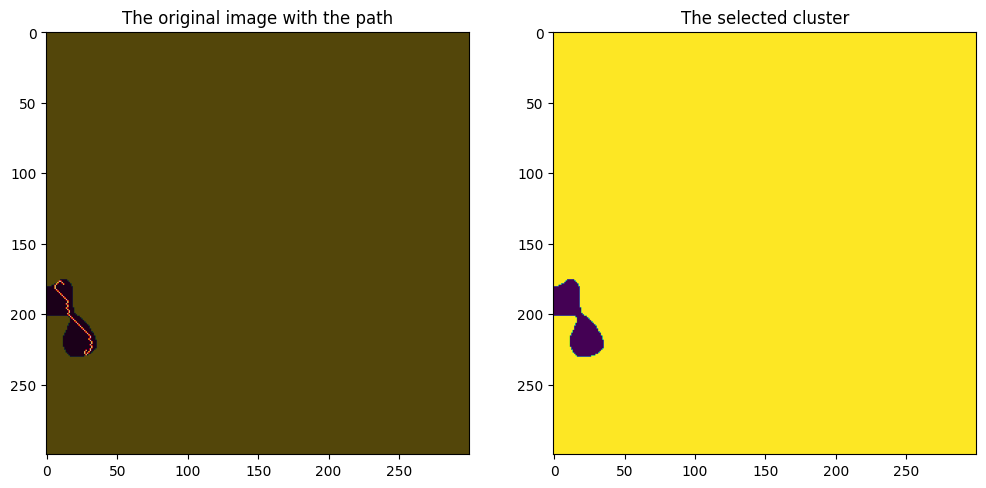

In [182]:
import matplotlib.pyplot as plt
random_show_results =  random.randint(0, len(list_tortuosity)-1)
#random_show_results = 0
# Supondo que 'image_temp' e 'path' já estejam definidos
# E que 'resultados_kmeans' e 'set_of_pores_index[random_index_apply_pore]' já estejam definidos

# Imprimir o índice do cluster
print("The index of the cluster in resultados_kmeans:", random_show_results)
# Imprimir o índice do cluster
print("The position of the path:", random_show_results, "The lengths distance of the path(L2):", list_path_distance[random_show_results])
print("The distance between the begin and final point of the path (L1):", list_max_distance[random_show_results])
print("The tortuosity based on the equation (L2/L1):", list_tortuosity[random_show_results])
# Criar uma figura com duas subfiguras lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 6))



# Mostrar a imagem original com o caminho sobreposto no primeiro subgráfico
axes[0].imshow(region_with_path[random_show_results])  # Mostrar a imagem original
axes[0].imshow(list_of_path[random_show_results], cmap='hot', alpha=0.7)  # Sobrepor o caminho em uma cor diferente e com transparência
axes[0].set_title('The original image with the path')

# Mostrar a imagem do cluster selecionado no segundo subgráfico
axes[1].imshow(region_with_path[random_show_results])
axes[1].set_title('The selected cluster')

# Exibir os gráficos
plt.show()

In [183]:
list_tortuosity.mean()

2.723244057609263

In [184]:
# Inicialize contadores para cada intervalo
intervalo_0_1 = 0
intervalo_1_2 = 0
intervalo_2_3 = 0
intervalo_3_8 = 0

# Itere sobre cada valor na lista
for valor in list_tortuosity:
    if 0 <= valor < 1:
        intervalo_0_1 += 1
    elif 1 <= valor < 2:
        intervalo_1_2 += 1
    elif 2 <= valor < 3:
        intervalo_2_3 += 1
    elif 3 <= valor < 8:
        intervalo_3_8 += 1

# Exibindo os resultados
print(f'Quantidade de valores no intervalo [0, 1): {intervalo_0_1}')
print(f'Quantidade de valores no intervalo [1, 2): {intervalo_1_2}')
print(f'Quantidade de valores no intervalo [2, 3): {intervalo_2_3}')
print(f'Quantidade de valores no intervalo [3, 8): {intervalo_3_8}')

Quantidade de valores no intervalo [0, 1): 0
Quantidade de valores no intervalo [1, 2): 10
Quantidade de valores no intervalo [2, 3): 3
Quantidade de valores no intervalo [3, 8): 4


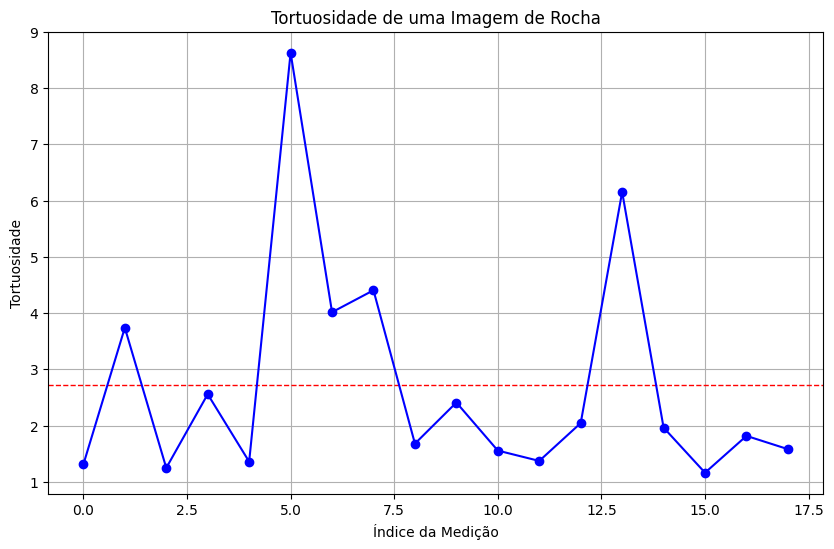

In [185]:
import matplotlib.pyplot as plt

# Criar o gráfico
plt.figure(figsize=(10, 6))


# Adicionar uma linha horizontal ao longo do valor zero no eixo y
plt.axhline(list_tortuosity.mean(), color='red', linestyle='--', linewidth=1)
plt.plot(list_tortuosity, marker='o', linestyle='-', color='b')

# Adicionar título e rótulos aos eixos
plt.title('Tortuosidade de uma Imagem de Rocha')
plt.xlabel('Índice da Medição')
plt.ylabel('Tortuosidade')

# Adicionar grade para melhor visualização
plt.grid(True)

# Exibir o gráfico
plt.show()

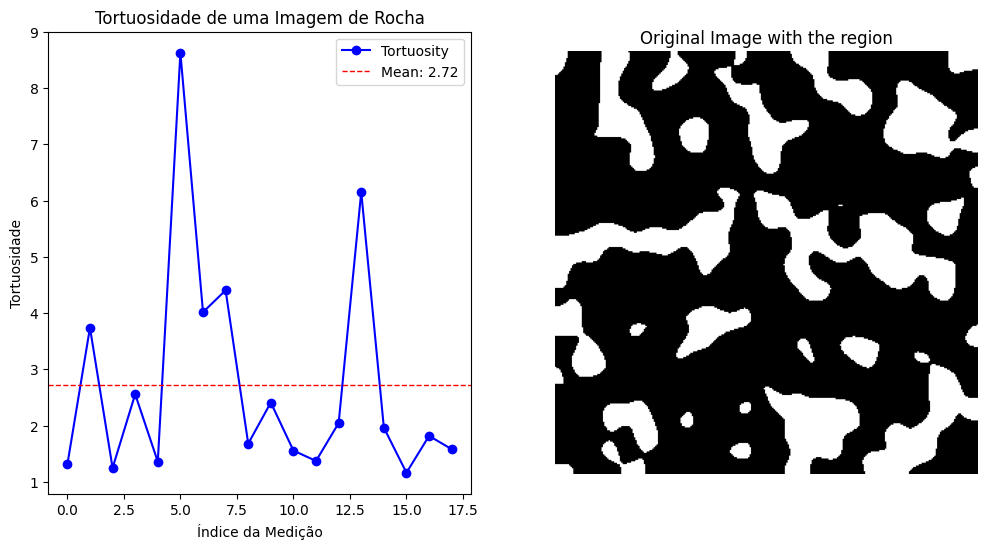

In [186]:
# Visualizar a região segmentada e as coordenadas
plt.figure(figsize=(12, 6))

# Primeiro gráfico: Tortuosidade
plt.subplot(121)
plt.plot(list_tortuosity, marker='o', linestyle='-', color='b', label='Tortuosity')
plt.axhline(list_tortuosity.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {list_tortuosity.mean():.2f}')

# Adicionar título e rótulos aos eixos
plt.title('Tortuosidade de uma Imagem de Rocha')
plt.xlabel('Índice da Medição')
plt.ylabel('Tortuosidade')

# Adicionar legenda
plt.legend()

# Segundo gráfico: Imagem binária com a região
plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.title('Original Image with the region')
plt.axis('off')

# Exibir o gráfico
plt.show()

## Apply the bfs (Breadth-First Search) to estimate the tortuosity in each void space (pore region)

In [187]:
import numpy as np
from collections import deque
from itertools import combinations

def euclidean_distance(p1, p2):
    return np.linalg.norm(np.array(p1) - np.array(p2))

def bfs_path(image, start, end):
    rows, cols = image.shape
    visited = np.full((rows, cols), False)
    parent = np.full((rows, cols, 2), -1, dtype=int)
    
    # Movimentos possíveis: cima, baixo, esquerda, direita
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    
    queue = deque([start])
    visited[start[0], start[1]] = True
    
    while queue:
        current = queue.popleft()
        
        if current == end:
            break
        
        for d in directions:
            nr, nc = current[0] + d[0], current[1] + d[1]
            
            if 0 <= nr < rows and 0 <= nc < cols and not visited[nr, nc] and image[nr, nc] == 0:
                queue.append((nr, nc))
                visited[nr, nc] = True
                parent[nr, nc] = current
    
    path = []
    if visited[end[0], end[1]]:
        current = end
        while current != start:
            path.append(current)
            current = tuple(parent[current[0], current[1]])
        path.append(start)
        path.reverse()
    
    return path

In [188]:
list_tortuosity = []
list_path_distance = []
list_of_path = []
list_max_distance = []
region_with_path = []

for idx in range(len(set_of_pores_index)):
    image_temp = list_connected_regions[idx]
    centers_temp = list_of_centers_connected_regions[idx]
    
    # Inicializar as variáveis para armazenar a maior distância e os centros correspondentes
    max_distance = 0
    farthest_centers = None
    
    # Iterar sobre todas as combinações possíveis de pares de centros
    for (i, j) in combinations(range(len(centers_temp)), 2):
        p1, p2 = centers_temp[i], centers_temp[j]
        dist = euclidean_distance(p1, p2)
        if dist > max_distance:
            max_distance = dist
            farthest_centers = (p1, p2)
    
    if farthest_centers is None:
        # Se não foi encontrado nenhum par de centros, continue para a próxima iteração
        continue
    
    # Coordenadas dos centros dos clusters
    start_float = farthest_centers[0]
    end_float = farthest_centers[1]

    # Converter coordenadas de ponto flutuante para inteiras
    start = (int(round(start_float[0])), int(round(start_float[1])))
    end = (int(round(end_float[0])), int(round(end_float[1])))
    
    try:
        # Encontrar o caminho de menor custo usando BFS
        path = bfs_path(image_temp, start, end)
        if not path:
            print(f"No path found between {start} and {end}. Skipping this pair.")
            continue
        
        # Marcar o caminho na imagem
        path_array = np.zeros_like(image_temp)
        for r, c in path:
            path_array[r, c] = 1
        
        # Calcular o comprimento do caminho
        path_length = 0
        for k in range(len(path) - 1):
            x1, y1 = path[k]
            x2, y2 = path[k + 1]
            distance_int = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
            path_length += distance_int
        
        tortuosity = path_length / max_distance
        
        # Append only valid results to the lists
        list_max_distance.append(max_distance)
        list_of_path.append(path_array)
        list_path_distance.append(path_length)
        #list_tortuosity.append(tortuosity)
        region_with_path.append(image_temp)
    except ValueError:
        print(f"No path found between {start} and {end}. Skipping this pair.")

In [189]:
# Converter listas para arrays do NumPy
array_path_distance = np.array(list_path_distance)
array_max_distance = np.array(list_max_distance)

# Calcular a tortuosidade
list_tortuosity = array_path_distance / array_max_distance

# Exibir o resultado
print(list_tortuosity)

[1.27996481 1.41947996 1.39264377 1.39725842 1.35280743 1.41601405
 1.28470533 1.33907182 1.33240792 1.33623296 1.26596879 1.37121314
 0.95573798 1.40588764 1.28102409 1.38741454 1.37254518 1.09964713]


In [190]:
#To comparison with (sinthetic model)
region_with_path[1].max(), region_with_path[1].min()

(1, 0)

In [191]:
len(list_tortuosity), len(list_path_distance), len(list_max_distance), len(list_of_path)

(18, 18, 18, 18)

In [192]:
max(list_max_distance), min(list_max_distance)

(148.60313967096192, 6.365678403331704)

In [193]:
len(list_tortuosity)

18

The index of the cluster in resultados_kmeans: 2
The position of the path: 2 The lengths distance of the path(L2): 84.0
The distance between the begin and final point of the path (L1): 60.31693236393234
The tortuosity based on the equation (L2/L1): 1.3926437686381645


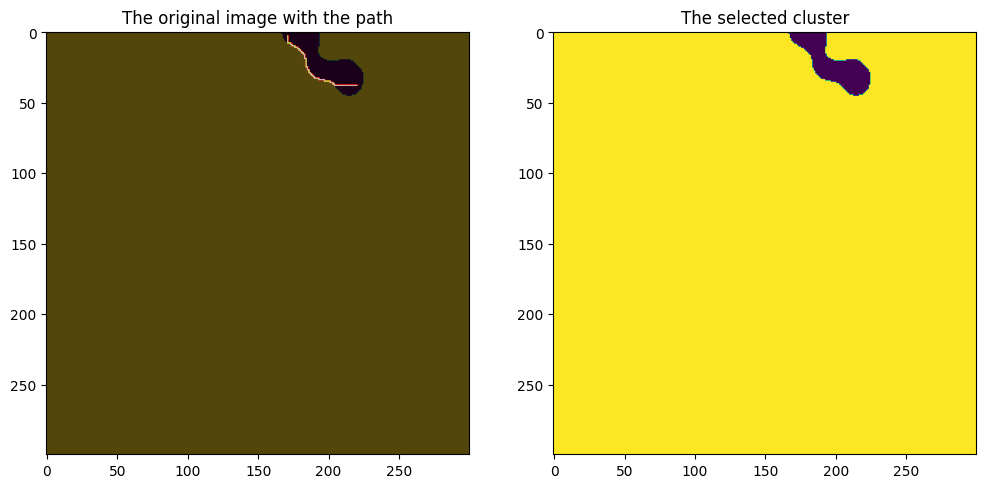

In [194]:
import matplotlib.pyplot as plt
random_show_results =  random.randint(0, len(list_tortuosity)-1)
#random_show_results = 0
# Supondo que 'image_temp' e 'path' já estejam definidos
# E que 'resultados_kmeans' e 'set_of_pores_index[random_index_apply_pore]' já estejam definidos

# Imprimir o índice do cluster
print("The index of the cluster in resultados_kmeans:", random_show_results)
# Imprimir o índice do cluster
print("The position of the path:", random_show_results, "The lengths distance of the path(L2):", list_path_distance[random_show_results])
print("The distance between the begin and final point of the path (L1):", list_max_distance[random_show_results])
print("The tortuosity based on the equation (L2/L1):", list_tortuosity[random_show_results])
# Criar uma figura com duas subfiguras lado a lado
fig, axes = plt.subplots(1, 2, figsize=(12, 6))



# Mostrar a imagem original com o caminho sobreposto no primeiro subgráfico
axes[0].imshow(region_with_path[random_show_results])  # Mostrar a imagem original
axes[0].imshow(list_of_path[random_show_results], cmap='hot', alpha=0.7)  # Sobrepor o caminho em uma cor diferente e com transparência
axes[0].set_title('The original image with the path')

# Mostrar a imagem do cluster selecionado no segundo subgráfico
axes[1].imshow(region_with_path[random_show_results])
axes[1].set_title('The selected cluster')

# Exibir os gráficos
plt.show()

In [195]:
list_tortuosity_np = np.array(list_tortuosity)

In [196]:
list_tortuosity_np.mean()

1.316112497882174

In [197]:
# Inicialize contadores para cada intervalo
intervalo_0_1 = 0
intervalo_1_2 = 0
intervalo_2_3 = 0
intervalo_3_8 = 0

# Itere sobre cada valor na lista
for valor in list_tortuosity:
    if 0 <= valor < 1:
        intervalo_0_1 += 1
    elif 1 <= valor < 2:
        intervalo_1_2 += 1
    elif 2 <= valor < 3:
        intervalo_2_3 += 1
    elif 3 <= valor < 8:
        intervalo_3_8 += 1

# Exibindo os resultados
print(f'Quantidade de valores no intervalo [0, 1): {intervalo_0_1}')
print(f'Quantidade de valores no intervalo [1, 2): {intervalo_1_2}')
print(f'Quantidade de valores no intervalo [2, 3): {intervalo_2_3}')
print(f'Quantidade de valores no intervalo [3, 8): {intervalo_3_8}')

Quantidade de valores no intervalo [0, 1): 1
Quantidade de valores no intervalo [1, 2): 17
Quantidade de valores no intervalo [2, 3): 0
Quantidade de valores no intervalo [3, 8): 0


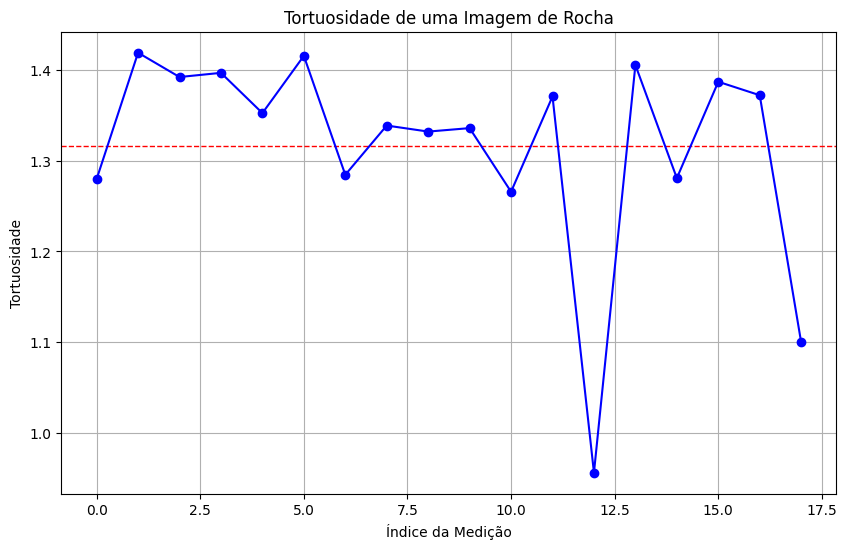

In [198]:
import matplotlib.pyplot as plt

# Criar o gráfico
plt.figure(figsize=(10, 6))


# Adicionar uma linha horizontal ao longo do valor zero no eixo y
plt.axhline(list_tortuosity_np.mean(), color='red', linestyle='--', linewidth=1)
plt.plot(list_tortuosity_np, marker='o', linestyle='-', color='b')

# Adicionar título e rótulos aos eixos
plt.title('Tortuosidade de uma Imagem de Rocha')
plt.xlabel('Índice da Medição')
plt.ylabel('Tortuosidade')

# Adicionar grade para melhor visualização
plt.grid(True)

# Exibir o gráfico
plt.show()

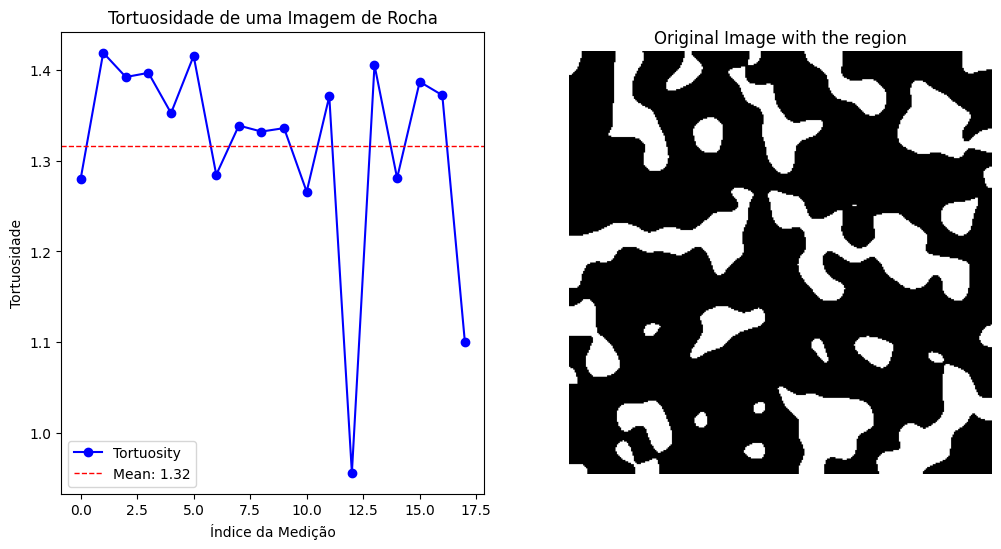

In [199]:
# Visualizar a região segmentada e as coordenadas
plt.figure(figsize=(12, 6))

# Primeiro gráfico: Tortuosidade
plt.subplot(121)
plt.plot(list_tortuosity_np, marker='o', linestyle='-', color='b', label='Tortuosity')
plt.axhline(list_tortuosity_np.mean(), color='red', linestyle='--', linewidth=1, label=f'Mean: {list_tortuosity_np.mean():.2f}')

# Adicionar título e rótulos aos eixos
plt.title('Tortuosidade de uma Imagem de Rocha')
plt.xlabel('Índice da Medição')
plt.ylabel('Tortuosidade')

# Adicionar legenda
plt.legend()

# Segundo gráfico: Imagem binária com a região
plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.title('Original Image with the region')
plt.axis('off')

# Exibir o gráfico
plt.show()